<a href="https://colab.research.google.com/github/DarthAsclepio/TELCOM_X_PT1_ALURA/blob/main/TELCOM_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  # **EXTRACCIÓN DE LOS DATOS**

In [166]:
import warnings
import requests
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

In [167]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
print(f'Total de registros obtenidos: {len(data)}')

Total de registros obtenidos: 7267


In [168]:
data = response.json()
df_raw = pd.DataFrame(data)
df_raw.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# **EXPLORANDO Y CONOCIENDO LOS DATOS**

In [169]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


# **TRANSFORMANDO LOS DATOS**

In [174]:
df = pd.json_normalize(data)
df.columns = [col.replace('customer.', '').replace('phone.', '').replace('internet.', '').replace('account.', '').replace('Charges.', '') for col in df.columns]
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   object 
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [185]:
for col in df.columns:
    print(f"\n✓ Columna: {col}")
    print(df[col].unique())


✓ Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

✓ Columna: Churn
['No' 'Yes' '']

✓ Columna: gender
['Female' 'Male']

✓ Columna: SeniorCitizen
['Unknown']

✓ Columna: Partner
['Yes' 'No']

✓ Columna: Dependents
['Yes' 'No']

✓ Columna: tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

✓ Columna: PhoneService
['Yes' 'No']

✓ Columna: MultipleLines
['No' 'Yes' 'No phone service']

✓ Columna: InternetService
['DSL' 'Fiber optic' 'No']

✓ Columna: OnlineSecurity
['No' 'Yes' 'No internet service']

✓ Columna: OnlineBackup
['Yes' 'No' 'No internet service']

✓ Columna: DeviceProtection
['No' 'Yes' 'No internet service']

✓ Columna: TechSupport
['Yes' 'No' 'No internet service']

✓ Columna: StreamingTV
['Yes' 'No' 'No internet service']

✓ Columna: Stre

# **DICCIONARIO**

# 1. Identificacion del Cliente:
- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa

# 2. Información del Cliente
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente

# 3. Servicios de Telefonía
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica

# 3. Servicios de internet

- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas

# 5. Información de la Cuenta
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

# **LIMPIANDO DATOS**

In [178]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
df['Monthly'] = pd.to_numeric(df['Monthly'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
print(df.dtypes)

customerID           object
Churn                object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Monthly             float64
Total               float64
dtype: object


In [191]:
print('='*60)
print('ANÁLISIS DE VALORES NULOS, VACÍOS Y DUPLICADOS')
print('='*60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Columna': missing.index,
    'Valores Nulos (NaN)': missing.values,
    'Porcentaje (%)': missing_pct.values
}).sort_values('Valores Nulos (NaN)', ascending=False)

missing_df_filtered = missing_df[missing_df['Valores Nulos (NaN)'] > 0]

if len(missing_df_filtered) > 0:
    print(f'\nSe encontraron {len(missing_df_filtered)} columnas con valores nulos:\n')
    print(missing_df_filtered.to_string(index=False))
else:
    print('\nNo se encontraron valores nulos (NaN) en el dataset')


print('\n' + '='*60)
print('ANÁLISIS DE CADENAS VACÍAS')
print('='*60)

empty_data = []

for col in df.select_dtypes(include='object').columns:
    empty_count = (df[col].astype(str).str.strip() == '').sum()
    if empty_count > 0:
        empty_pct = (empty_count / len(df)) * 100
        empty_data.append({
            'Columna': col,
            'Valores Vacíos': empty_count,
            'Porcentaje (%)': empty_pct
        })

empty_df = pd.DataFrame(empty_data).sort_values('Valores Vacíos', ascending=False)

if not empty_df.empty:
    print(f'\nSe encontraron {len(empty_df)} columnas con cadenas vacías:\n')
    print(empty_df.to_string(index=False))
else:
    print('\nNo se encontraron cadenas vacías en columnas tipo object')


print('\n' + '='*60)
print('ANÁLISIS DE DUPLICADOS')
print('='*60)

duplicados = df.duplicated().sum()
print(f'\nRegistros duplicados encontrados: {duplicados}')

if duplicados > 0:
    print('⚠ Se recomienda revisar y eliminar los duplicados')
else:
    print('No se encontraron registros duplicados')


ANÁLISIS DE VALORES NULOS, VACÍOS Y DUPLICADOS

No se encontraron valores nulos (NaN) en el dataset

ANÁLISIS DE CADENAS VACÍAS

Se encontraron 1 columnas con cadenas vacías:

Columna  Valores Vacíos  Porcentaje (%)
  Churn             224        3.082427

ANÁLISIS DE DUPLICADOS

Registros duplicados encontrados: 0
No se encontraron registros duplicados


In [193]:

print('='*60)
print('INICIO DEL PROCESO DE LIMPIEZA')
print('='*60)


if 'Churn' in df.columns:
    mask_empty_churn = (df['Churn'].astype(str).str.strip() == '')
    initial_churn_empty_count = mask_empty_churn.sum()
    if initial_churn_empty_count > 0:
        df.loc[mask_empty_churn, 'Churn'] = np.nan
        print(f'  • {initial_churn_empty_count} cadenas vacías en "Churn" convertidas a NaN.')
    else:
        print('  • No se encontraron cadenas vacías en "Churn" para convertir a NaN.')


print('\n' + '='*60)
print('TRATAMIENTO DE CADENAS VACÍAS/ESPACIOS A NaN')
print('='*60)

empty_strings_handled_count = 0
for col in df.columns:

    if df[col].dtype == 'object' or isinstance(df[col].dtype, pd.CategoricalDtype):
        if col == 'Churn':
            continue

        initial_empty_count = (df[col].astype(str).str.strip() == '').sum()
        if initial_empty_count > 0:
            if isinstance(df[col].dtype, pd.CategoricalDtype):
                df[col] = df[col].replace('', np.nan)
            else:
                df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)

            empty_strings_handled_count += initial_empty_count
            print(f'  • Columna "{col}" ({df[col].dtype}): {initial_empty_count} cadenas vacías/espacios convertidos a NaN.')

if empty_strings_handled_count == 0:
    print('No se encontraron cadenas vacías o con solo espacios para convertir a NaN en otras columnas object/category.')
else:
    print(f'Total de {empty_strings_handled_count} cadenas vacías/espacios convertidos a NaN en otras columnas.')


print('\n' + '='*60)
print('ANÁLISIS Y ELIMINACIÓN DE REGISTROS DUPLICADOS')
print('='*60)

duplicados = df.duplicated().sum()

if duplicados > 0:
    print(f'Registros duplicados encontrados: {duplicados}')
    df.drop_duplicates(inplace=True)
    print('Registros duplicados eliminados.')
else:
    print('No se encontraron registros duplicados.')


print('\n' + '='*60)
print('MANEJO ESTRATÉGICO Y GENERAL DE VALORES NULOS (NaN)')
print('='*60)

nulos_iniciales = df.isnull().sum().sum()
if nulos_iniciales > 0:
    print(f'\nSe encontraron {nulos_iniciales} valores nulos en el dataset antes del tratamiento de imputación.')

    if 'Total' in df.columns:
        nulls_for_tenure_zero = df[(df['tenure'] == 0) & (df['Total'].isnull())].shape[0]
        if nulls_for_tenure_zero > 0:
            df.loc[(df['tenure'] == 0) & (df['Total'].isnull()), 'Total'] = 0
            print(f'  • {nulls_for_tenure_zero} valores nulos en "Total" (donde tenure=0) imputados a 0.')

        remaining_charges_total_nulls = df['Total'].isnull().sum()
        if remaining_charges_total_nulls > 0:
            median_charges_total = df['Total'].median()
            df['Total'].fillna(median_charges_total, inplace=True)
            print(f'  • {remaining_charges_total_nulls} valores nulos restantes en "Total" imputados con la mediana ({median_charges_total:.2f}).')
        else:
            print('  • No se encontraron valores nulos pendientes en "Total" para imputar.')
    else:
        print('  • La columna "Total" no está presente, se omite tratamiento específico.')

    churn_nulls = df['Churn'].isnull().sum()
    if churn_nulls > 0:
        print(f'  • Se encontraron {churn_nulls} valores nulos en la columna "Churn". Procediendo a eliminar estas filas.')
        df.dropna(subset=['Churn'], inplace=True)
        print('Filas con valores nulos en "Churn" eliminadas.')

    nulos_despues_especificos = df.isnull().sum()
    columnas_con_nulos_restantes = nulos_despues_especificos[nulos_despues_especificos > 0]

    if not columnas_con_nulos_restantes.empty:
        print('\nSe encontraron valores nulos en otras columnas. Aplicando imputación general:')
        for col in columnas_con_nulos_restantes.index:
            if pd.api.types.is_numeric_dtype(df[col]):
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f'  • Columna "{col}" (numérica): {columnas_con_nulos_restantes[col]} nulos imputados con la mediana ({median_val:.2f}).')
            elif isinstance(df[col].dtype, pd.CategoricalDtype):
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                print(f'  • Columna "{col}" (categórica): {columnas_con_nulos_restantes[col]} nulos imputados con la moda ("{mode_val}").')
            elif df[col].dtype == 'object':
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                print(f'  • Columna "{col}" (object): {columnas_con_nulos_restantes[col]} nulos imputados con la moda ("{mode_val}").')
            else:
                print(f'  • Columna "{col}" (otro tipo): {columnas_con_nulos_restantes[col]} nulos no imputados, tipo no reconocido.')
    else:
        print('No se encontraron valores nulos restantes en otras columnas.')
else:
    print('No se encontraron valores nulos iniciales en el dataset.')


print('\n' + '='*60)
print('VERIFICACIÓN FINAL DE LIMPIEZA')
print('='*60)

final_nulos_count = df.isnull().sum().sum()
print(f'Registros finales: {df.shape[0]}')
print(f'Columnas finales: {df.shape[1]}')
print(f'Nulos restantes en todo el dataset: {final_nulos_count}')

if final_nulos_count == 0:
    print('\nDataset limpio y listo para Análisis Exploratorio (EDA)')
else:
    print('\nAún quedan valores nulos en el dataset. Revisar el proceso de limpieza.')

INICIO DEL PROCESO DE LIMPIEZA
  • No se encontraron cadenas vacías en "Churn" para convertir a NaN.

TRATAMIENTO DE CADENAS VACÍAS/ESPACIOS A NaN
No se encontraron cadenas vacías o con solo espacios para convertir a NaN en otras columnas object/category.

ANÁLISIS Y ELIMINACIÓN DE REGISTROS DUPLICADOS
No se encontraron registros duplicados.

MANEJO ESTRATÉGICO Y GENERAL DE VALORES NULOS (NaN)
No se encontraron valores nulos iniciales en el dataset.

VERIFICACIÓN FINAL DE LIMPIEZA
Registros finales: 7043
Columnas finales: 21
Nulos restantes en todo el dataset: 0

Dataset limpio y listo para Análisis Exploratorio (EDA)


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [195]:
df['daily_account'] = df['Monthly'] / 30
df.head(3)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,daily_account
0,0002-ORFBO,No,Female,Unknown,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,Unknown,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,Unknown,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333


# **ANÁLISIS DE DATOS**

ANÁLISIS DE CHURN

Distribución de Churn:
  • No (Clientes activos): 5,174 (73.46%)
  • Yes (Clientes perdidos): 1,869 (26.54%)

 Tasa de Churn: 26.54%


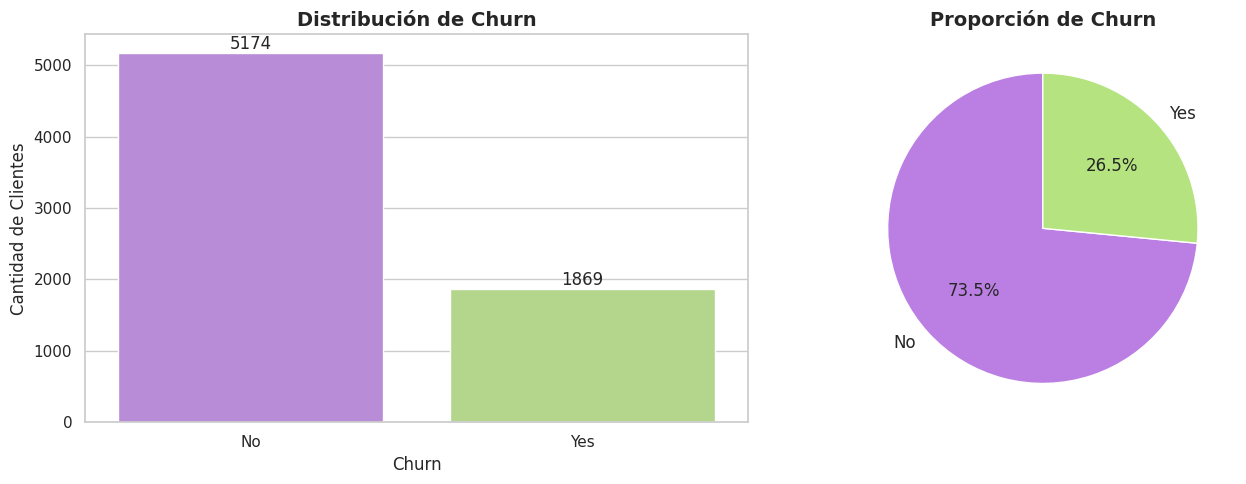

In [211]:
print('='*60)
print('ANÁLISIS DE CHURN')
print('='*60)

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f'\nDistribución de Churn:')
print(f'  • No (Clientes activos): {churn_counts["No"]:,} ({churn_pct["No"]:.2f}%)')
print(f'  • Yes (Clientes perdidos): {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.2f}%)')
print(f'\n Tasa de Churn: {churn_pct["Yes"]:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Churn', hue='Churn', palette=['#BB7FE3', '#B4E37F'], ax=axes[0], legend=False)
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

colors = ['#BB7FE3', '#B4E37F']
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()

if not os.path.exists('imgs'):
    os.makedirs('imgs')
    print("Directory 'imgs' created.")

plt.savefig('imgs/01_distribucion_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# **ANALISIS DEMOGRAFICO**

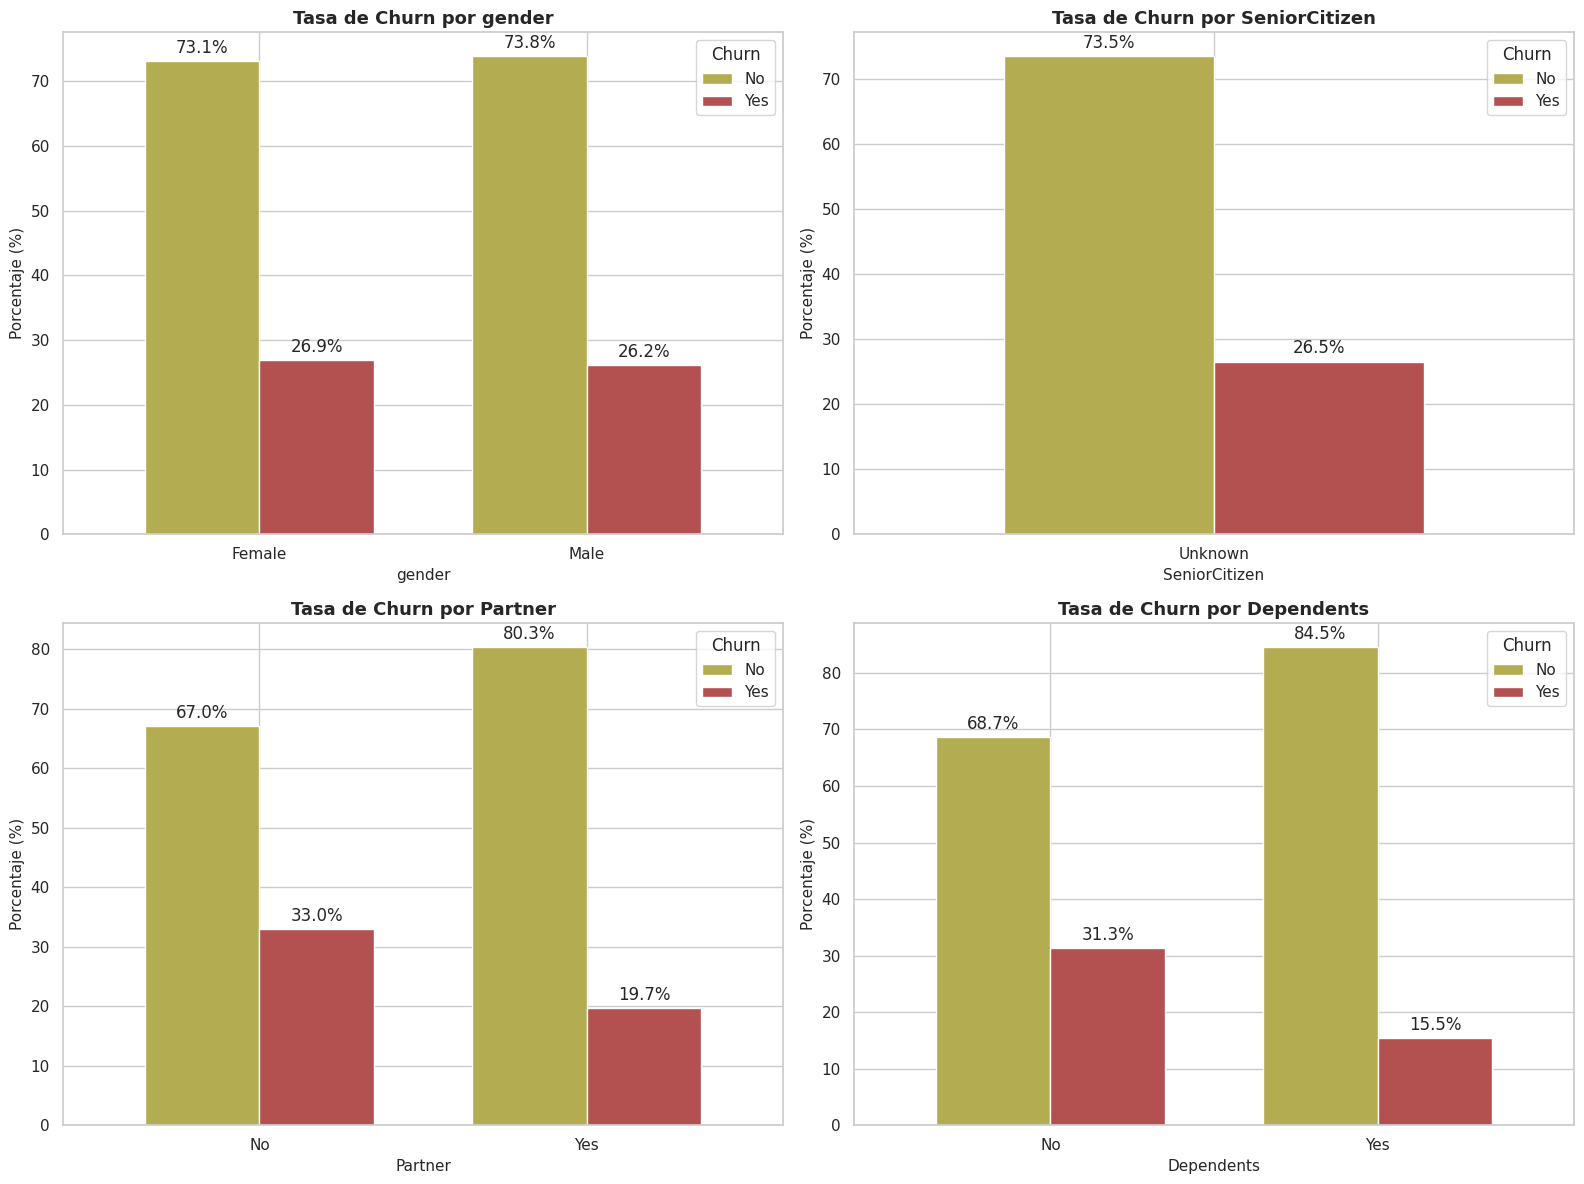

RESUMEN: CHURN POR CARACTERÍSTICAS DEMOGRÁFICAS

gender:
  • Female: 26.92% de churn
  • Male: 26.16% de churn

SeniorCitizen:
  • Unknown: 26.54% de churn

Partner:
  • No: 32.96% de churn
  • Yes: 19.66% de churn

Dependents:
  • No: 31.28% de churn
  • Yes: 15.45% de churn


In [216]:
demographic_vars = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, var in enumerate(demographic_vars):
    churn_by_var = pd.crosstab(df[var], df['Churn'], normalize='index') * 100

    churn_by_var.plot(kind='bar', ax=axes[idx], color=['#B3AC50', '#B35050'], width=0.7)
    axes[idx].set_title(f'Tasa de Churn por {var}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel(var, fontsize=11)
    axes[idx].set_ylabel('Porcentaje (%)', fontsize=11)
    axes[idx].legend(title='Churn', labels=['No', 'Yes'])
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)

    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.savefig('imgs/02_analisis_demografico.png', dpi=300, bbox_inches='tight')
plt.show()

print('='*60)
print('RESUMEN: CHURN POR CARACTERÍSTICAS DEMOGRÁFICAS')
print('='*60)
for var in demographic_vars:
    churn_rate = df.groupby(var)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
    print(f'\n{var}:')
    for category, rate in churn_rate.items():
        print(f'  • {category}: {rate:.2f}% de churn')

# **ANÁLISIS DE PERMANENCIA**

ANÁLISIS DE PERMANENCIA (TENURE)

Estadísticas generales de Tenure (meses):
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Tenure promedio por Churn:
            mean  median        std
Churn                              
No     37.569965    38.0  24.113777
Yes    17.979133    10.0  19.531123


/tmp/ipykernel_166/167735217.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette=['#4F0303', '#03424F'], ax=axes[0])
/tmp/ipykernel_166/167735217.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure_group = df.groupby('tenure_group')['Churn'].apply(


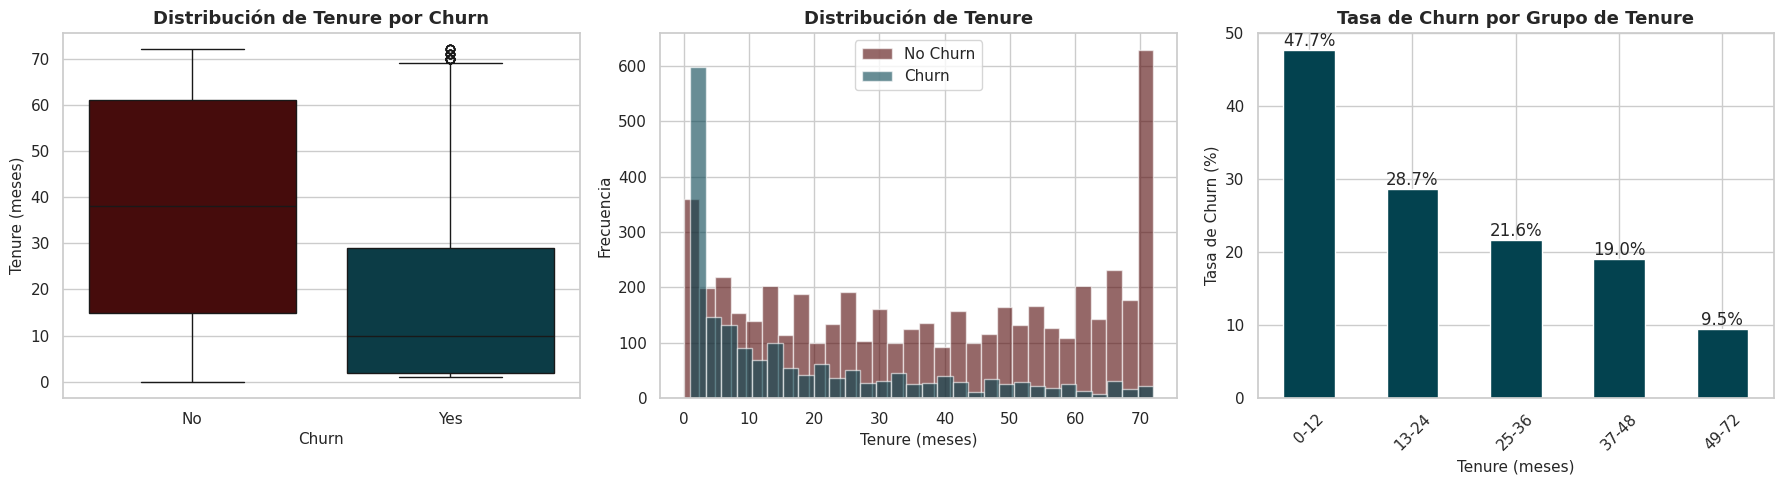

In [221]:
print('='*60)
print('ANÁLISIS DE PERMANENCIA (TENURE)')
print('='*60)
print(f'\nEstadísticas generales de Tenure (meses):')
print(df['tenure'].describe())

print(f'\nTenure promedio por Churn:')
tenure_by_churn = df.groupby('Churn')['tenure'].agg(['mean', 'median', 'std'])
print(tenure_by_churn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Churn', y='tenure', palette=['#4F0303', '#03424F'], ax=axes[0])
axes[0].set_title('Distribución de Tenure por Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=11)
axes[0].set_ylabel('Tenure (meses)', fontsize=11)

df[df['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.6, label='No Churn',
                                         color='#4F0303', ax=axes[1])
df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.6, label='Churn',
                                          color='#03424F', ax=axes[1])
axes[1].set_title('Distribución de Tenure', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (meses)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].legend()

df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 72],
                             labels=['0-12', '13-24', '25-36', '37-48', '49-72'])
churn_by_tenure_group = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
churn_by_tenure_group.plot(kind='bar', color='#03424F', ax=axes[2])
axes[2].set_title('Tasa de Churn por Grupo de Tenure', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Tenure (meses)', fontsize=11)
axes[2].set_ylabel('Tasa de Churn (%)', fontsize=11)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.savefig('imgs/03_analisis_permanencia.png', dpi=300, bbox_inches='tight')
plt.show()

# **ANÁLISIS DE SERVICIOS**

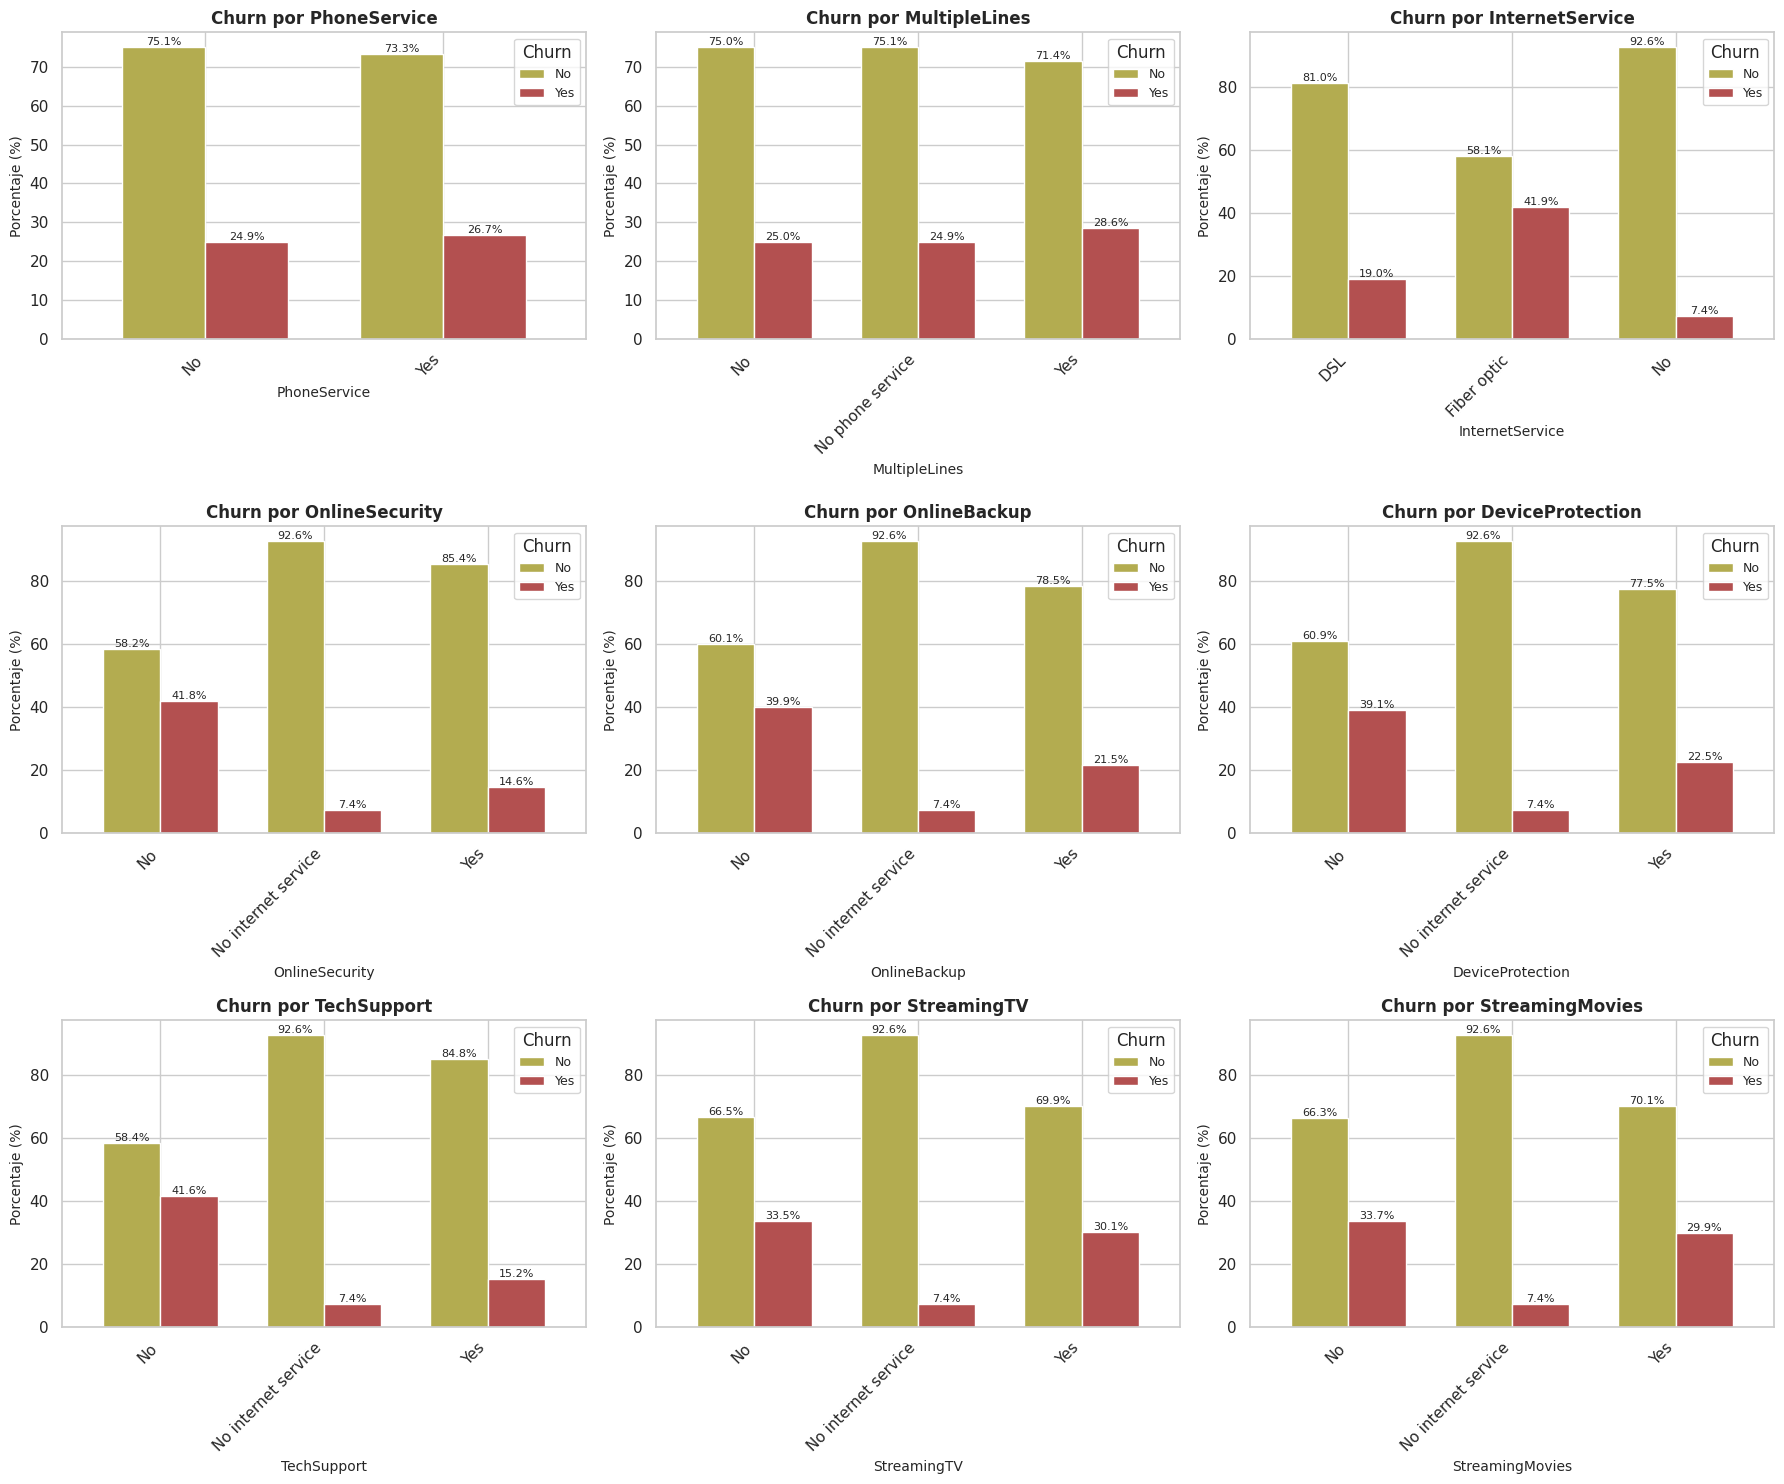

SERVICIOS CON MAYOR IMPACTO EN CHURN

* PhoneService:
  • No: 24.93% de churn
  • Yes: 26.71% de churn

* MultipleLines:
  • No: 25.04% de churn
  • No phone service: 24.93% de churn
  • Yes: 28.61% de churn

* InternetService:
  • DSL: 18.96% de churn
  • Fiber optic: 41.89% de churn
  • No: 7.40% de churn

* OnlineSecurity:
  • No: 41.77% de churn
  • No internet service: 7.40% de churn
  • Yes: 14.61% de churn

* OnlineBackup:
  • No: 39.93% de churn
  • No internet service: 7.40% de churn
  • Yes: 21.53% de churn

* DeviceProtection:
  • No: 39.13% de churn
  • No internet service: 7.40% de churn
  • Yes: 22.50% de churn

* TechSupport:
  • No: 41.64% de churn
  • No internet service: 7.40% de churn
  • Yes: 15.17% de churn

* StreamingTV:
  • No: 33.52% de churn
  • No internet service: 7.40% de churn
  • Yes: 30.07% de churn

* StreamingMovies:
  • No: 33.68% de churn
  • No internet service: 7.40% de churn
  • Yes: 29.94% de churn


In [222]:
service_vars = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

churn_rates = {}
for var in service_vars:
    churn_rate = df.groupby(var)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).to_dict()
    churn_rates[var] = churn_rate

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, var in enumerate(service_vars):
    churn_by_service = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    churn_by_service.plot(kind='bar', ax=axes[idx], color=['#B3AC50', '#B35050'], width=0.7)
    axes[idx].set_title(f'Churn por {var}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(var, fontsize=10)
    axes[idx].set_ylabel('Porcentaje (%)', fontsize=10)
    axes[idx].legend(title='Churn', labels=['No', 'Yes'], fontsize=9)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', fontsize=8)

plt.tight_layout()
plt.savefig('imgs/04_analisis_servicios.png', dpi=300, bbox_inches='tight')
plt.show()

print('='*60)
print('SERVICIOS CON MAYOR IMPACTO EN CHURN')
print('='*60)
for var in service_vars:
    print(f'\n* {var}:')
    for category, rate in churn_rates[var].items():
        print(f'  • {category}: {rate:.2f}% de churn')

# **ANÁLISIS DE SERVICIOS Y FACTURACIÓN**

ANÁLISIS DE GASTO DIARIO VS CHURN


/tmp/ipykernel_166/2257885896.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='daily_account', data=df, palette=['#BB7FE3', '#B4E37F'])


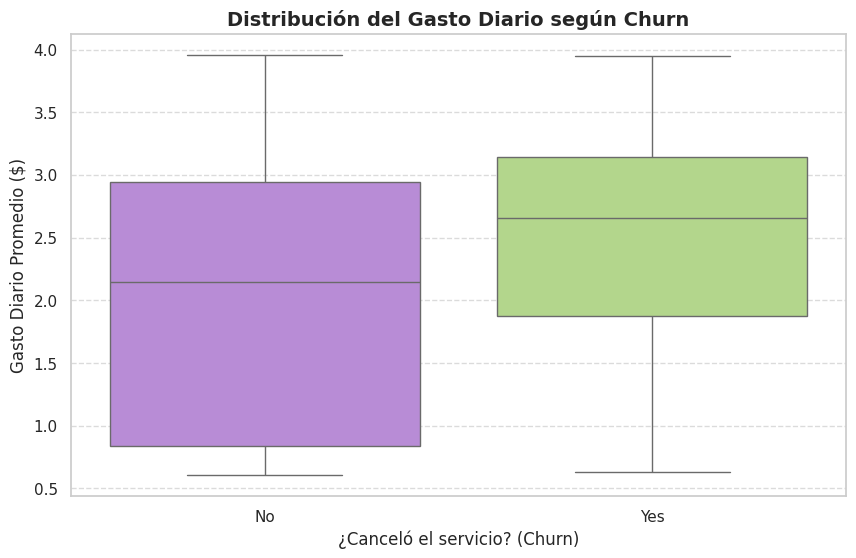


Estadísticas de Gasto Diario por Churn:
           mean     50%       min       max
Churn                                      
No     2.042171  2.1475  0.608333  3.958333
Yes    2.481378  2.6550  0.628333  3.945000


In [224]:
import matplotlib.pyplot as plt
import seaborn as sns

print('='*60)
print('ANÁLISIS DE GASTO DIARIO VS CHURN')
print('='*60)

plt.figure(figsize=(10, 6))

sns.boxplot(x='Churn', y='daily_account', data=df, palette=['#BB7FE3', '#B4E37F'])

plt.title('Distribución del Gasto Diario según Churn', fontsize=14, fontweight='bold')
plt.ylabel('Gasto Diario Promedio ($)', fontsize=12)
plt.xlabel('¿Canceló el servicio? (Churn)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('imgs/04_1_analisis_gasto_diario.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nEstadísticas de Gasto Diario por Churn:")
print(df.groupby('Churn')['daily_account'].describe()[['mean', '50%', 'min', 'max']])

# **RELACIÓN SERVICIO / ABANDONO**


Nueva columna creada: 'num_services' (Rango: 1 - 9 servicios)


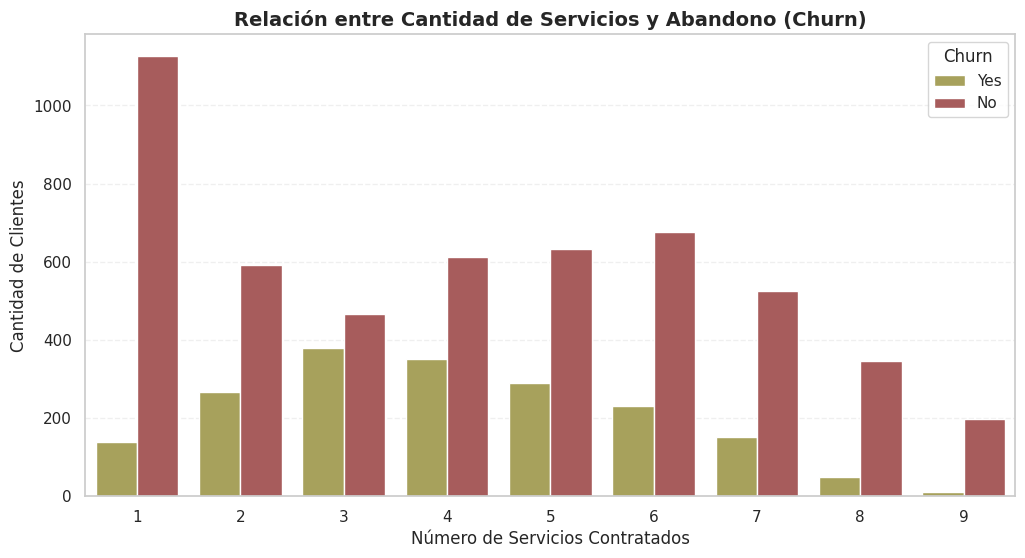


Porcentaje de abandono (Churn Rate) según cantidad de servicios:
num_services
1    10.917722
2    30.966240
3    44.917258
4    36.476684
5    31.344902
6    25.550661
7    22.485207
8    12.405063
9     5.288462
Name: Yes, dtype: float64


In [226]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

def count_services(row):
    count = 0
    if row['InternetService'] != 'No':
        count += 1

    for col in service_cols:
        if col != 'InternetService' and row[col] == 'Yes':
            count += 1
    return count

df['num_services'] = df.apply(count_services, axis=1)

print(f"\nNueva columna creada: 'num_services' (Rango: {df['num_services'].min()} - {df['num_services'].max()} servicios)")

plt.figure(figsize=(12, 6))

sns.countplot(x='num_services', hue='Churn', data=df, palette=['#B3AC50', '#B35050'])

plt.title('Relación entre Cantidad de Servicios y Abandono (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Servicios Contratados', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.legend(title='Churn', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('imgs/04_2_analisis_cantidad_servicios.png', dpi=300, bbox_inches='tight')
plt.show()

churn_rate_services = df.groupby('num_services')['Churn'].value_counts(normalize=True).unstack()
if 'Yes' in churn_rate_services.columns:
    print("\nPorcentaje de abandono (Churn Rate) según cantidad de servicios:")
    print((churn_rate_services['Yes'] * 100).sort_index())
else:
    print("\nNo se encontraron casos de Churn (Yes) para agrupar.")

# **ANÁLISIS DE CONTRATACIÓN Y FACTURACIÓN**

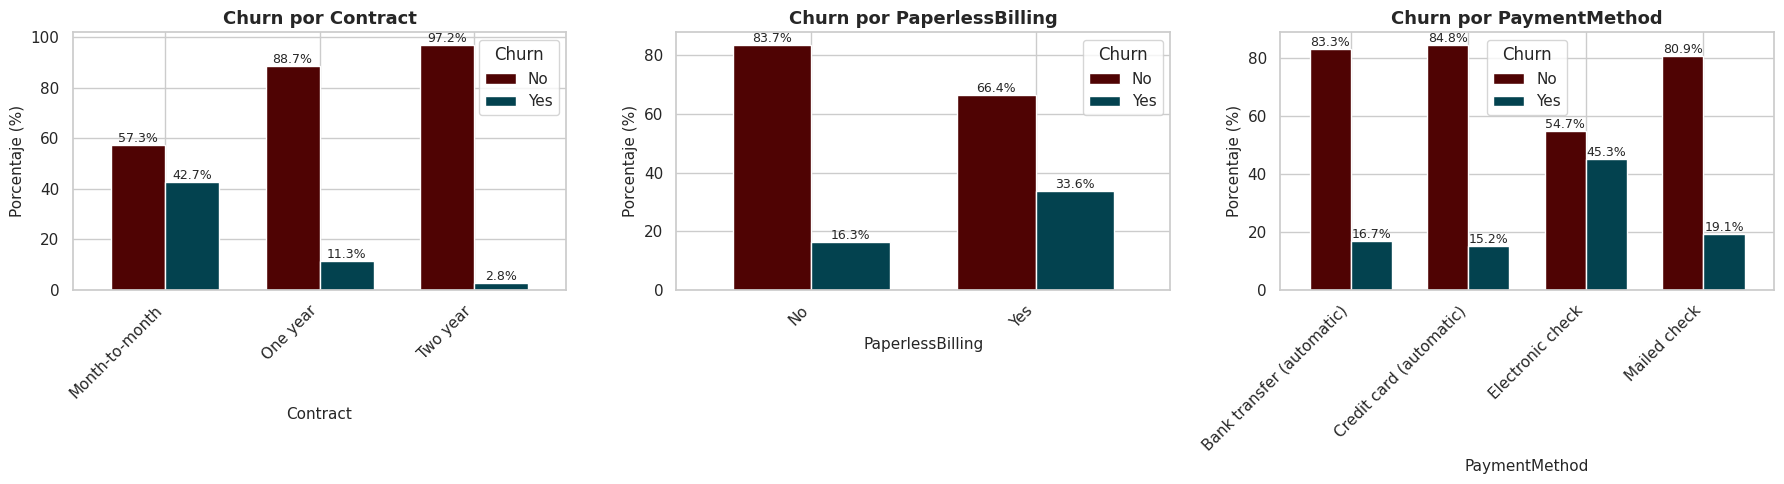

ANÁLISIS DE CONTRATO Y FACTURACIÓN

* Contract:
  • Month-to-month: 42.71% de churn
  • One year: 11.27% de churn
  • Two year: 2.83% de churn

* PaperlessBilling:
  • No: 16.33% de churn
  • Yes: 33.57% de churn

* PaymentMethod:
  • Bank transfer (automatic): 16.71% de churn
  • Credit card (automatic): 15.24% de churn
  • Electronic check: 45.29% de churn
  • Mailed check: 19.11% de churn


In [228]:
account_vars = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, var in enumerate(account_vars):
    churn_by_var = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    churn_by_var.plot(kind='bar', ax=axes[idx], color=['#4F0303', '#03424F'], width=0.7)
    axes[idx].set_title(f'Churn por {var}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel(var, fontsize=11)
    axes[idx].set_ylabel('Porcentaje (%)', fontsize=11)
    axes[idx].legend(title='Churn', labels=['No', 'Yes'])
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.savefig('imgs/05_analisis_contratos.png', dpi=300, bbox_inches='tight')
plt.show()

print('='*60)
print('ANÁLISIS DE CONTRATO Y FACTURACIÓN')
print('='*60)
for var in account_vars:
    churn_rate = df.groupby(var)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    )
    print(f'\n* {var}:')
    for category, rate in churn_rate.items():
        print(f'  • {category}: {rate:.2f}% de churn')

# **CARGOS MENSUALES Y TOTALES**

ANÁLISIS DE CARGOS

 Cargos Mensuales (MonthlyCharges):
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35

 Cargos Totales (TotalCharges):
        count         mean          std    min    25%       50%      75%  \
Churn                                                                      
No     5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30   

           max  
Churn           
No     8672.45  
Yes    8684.80  


/tmp/ipykernel_166/1280153312.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Monthly', palette=['#4F0303', '#03424F'], ax=axes[0, 0])
/tmp/ipykernel_166/1280153312.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Total', palette=['#4F0303', '#03424F'], ax=axes[1, 0])


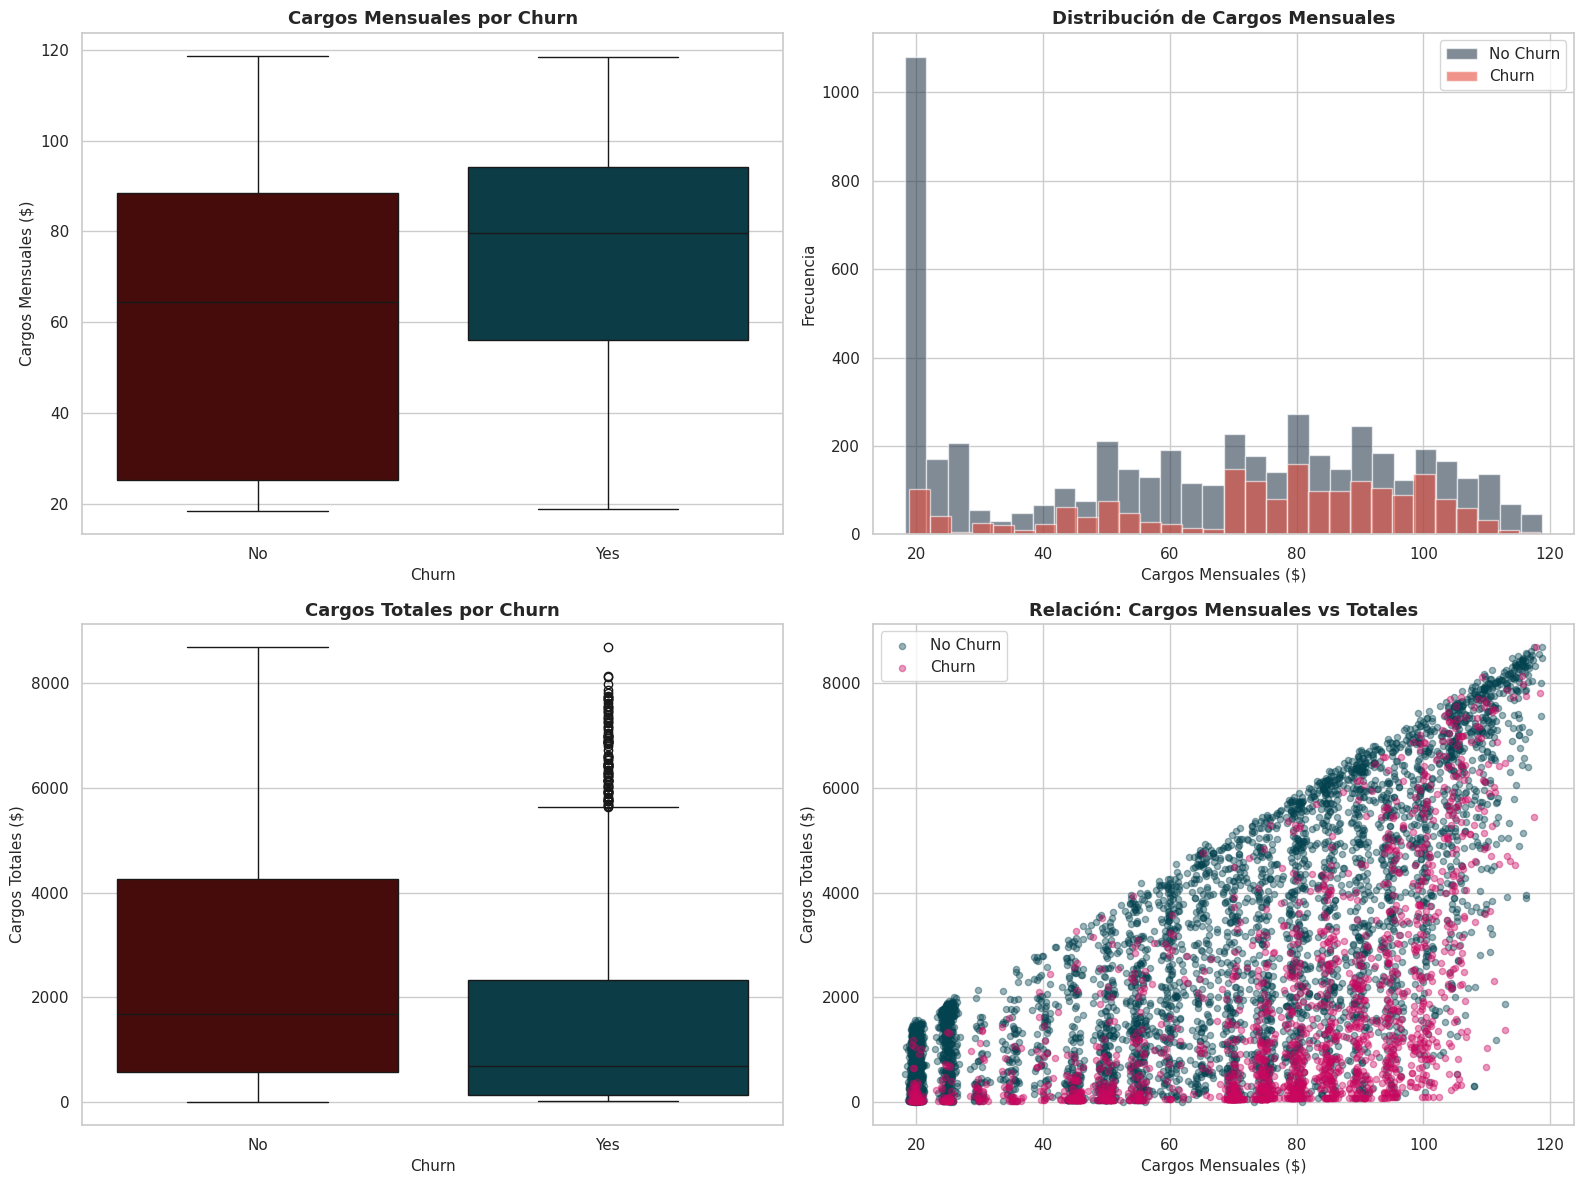

In [233]:
print('='*60)
print('ANÁLISIS DE CARGOS')
print('='*60)

print('\n Cargos Mensuales (MonthlyCharges):')
print(df.groupby('Churn')['Monthly'].describe())

print('\n Cargos Totales (TotalCharges):')
print(df.groupby('Churn')['Total'].describe())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df, x='Churn', y='Monthly', palette=['#4F0303', '#03424F'], ax=axes[0, 0])
axes[0, 0].set_title('Cargos Mensuales por Churn', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Churn', fontsize=11)
axes[0, 0].set_ylabel('Cargos Mensuales ($)', fontsize=11)

df[df['Churn'] == 'No']['Monthly'].hist(bins=30, alpha=0.6, label='No Churn',
                                                 color='#2C3E50', ax=axes[0, 1])
df[df['Churn'] == 'Yes']['Monthly'].hist(bins=30, alpha=0.6, label='Churn',
                                                  color='#E74C3C', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Cargos Mensuales', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Cargos Mensuales ($)', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].legend()

sns.boxplot(data=df, x='Churn', y='Total', palette=['#4F0303', '#03424F'], ax=axes[1, 0])
axes[1, 0].set_title('Cargos Totales por Churn', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Churn', fontsize=11)
axes[1, 0].set_ylabel('Cargos Totales ($)', fontsize=11)

for churn_val, color, label in [('No', '#03424F', 'No Churn'), ('Yes', '#CA075F', 'Churn')]:
    data_subset = df[df['Churn'] == churn_val]
    axes[1, 1].scatter(data_subset['Monthly'], data_subset['Total'],
                       alpha=0.4, c=color, label=label, s=20)
axes[1, 1].set_title('Relación: Cargos Mensuales vs Totales', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Cargos Mensuales ($)', fontsize=11)
axes[1, 1].set_ylabel('Cargos Totales ($)', fontsize=11)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('imgs/06_analisis_cargos.png', dpi=300, bbox_inches='tight')
plt.show()

# **CORRELACIÓN DE DATOS**

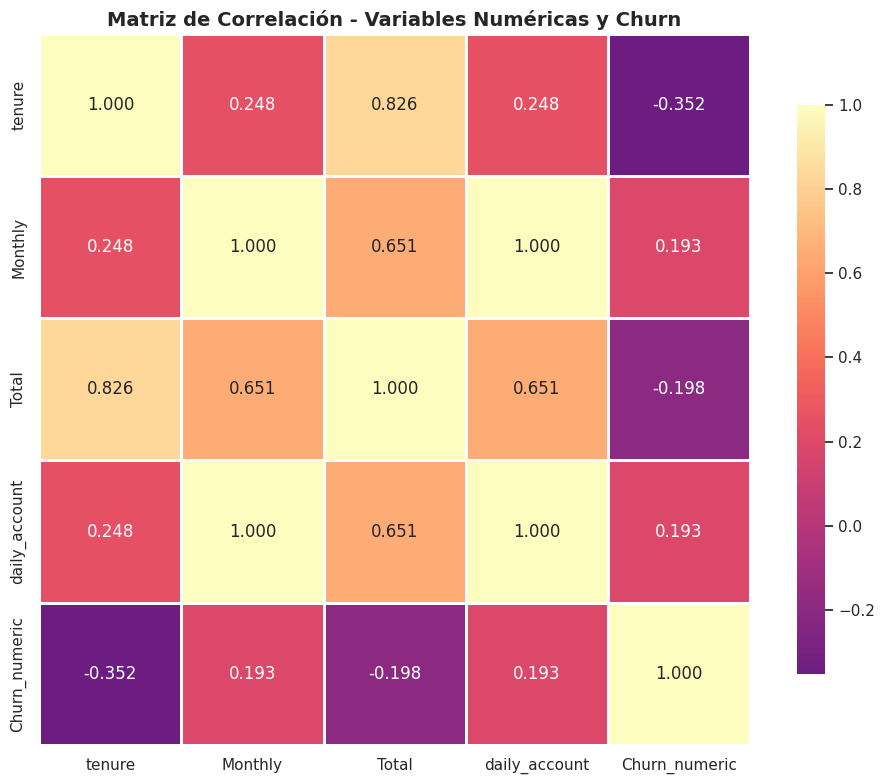

CORRELACIÓN CON CHURN

 Variables ordenadas por correlación con Churn:
  • Monthly: 0.1934
  • daily_account: 0.1934
  • Total: -0.1983
  • tenure: -0.3522


In [237]:
numeric_vars = ['tenure', 'Monthly', 'Total', 'daily_account']

df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

correlation_vars = numeric_vars + ['Churn_numeric']
corr_matrix = df[correlation_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='magma', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8}, fmt='.3f')
plt.title('Matriz de Correlación - Variables Numéricas y Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('imgs/07_matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print('='*60)
print('CORRELACIÓN CON CHURN')
print('='*60)
churn_corr = corr_matrix['Churn_numeric'].sort_values(ascending=False)
print('\n Variables ordenadas por correlación con Churn:')
for var, corr in churn_corr.items():
    if var != 'Churn_numeric':
        print(f'  • {var}: {corr:.4f}')

# **EXPORTACIÓN DE DATOS**

In [239]:
df_export = df.drop(['tenure_group', 'Churn_numeric'], axis=1, errors='ignore')

output_file = 'TELCOM_DATOS_CLEAN.csv'
df_export.to_csv(output_file, index=False, encoding='utf-8')

# **HALLAZGOS Y CONCLUSIONES**

## Hallazgos Clave del Análisis

*   **Alta Tasa de Churn:** La empresa enfrenta una tasa de abandono significativa, representando una considerable pérdida de ingresos.
*   **Factores Demográficos:** Los **adultos mayores** y los clientes **sin pareja o dependientes** muestran una mayor propensión al churn. El género no es un factor diferenciador.
*   **Permanencia (Tenure):** Los **clientes nuevos (0-12 meses)** son el grupo de mayor riesgo de abandono, mientras que los **clientes a largo plazo (>24 meses)** son significativamente más leales, destacando la importancia crítica de la retención inicial.
*   **Servicios:** El servicio de **Fibra Óptica** está asociado a un mayor churn. Por otro lado, la ausencia de servicios como **OnlineSecurity, OnlineBackup y TechSupport** incrementa el riesgo de abandono; estos actúan como protectores contra el churn.
*   **Tipo de Contrato:** Los contratos **'Month-to-month'** presentan una tasa de churn extremadamente alta, siendo uno de los predictores más fuertes. Los **contratos de 1 a 2 años** tienen tasas mucho menores.
*   **Método de Pago:** El pago mediante **'Electronic check'** se correlaciona con un mayor churn, mientras que los **pagos automáticos** (transferencia bancaria, tarjeta de crédito) fomentan la retención.
*   **Cargos:** Los **cargos mensuales altos** y los **cargos totales bajos** (indicativos de clientes nuevos) están relacionados con un mayor riesgo de abandono, lo que sugiere una percepción crítica del valor frente al precio.

## Recomendaciones Estratégicas

1.  **Programa de Retención para Clientes Nuevos:** Implementar un programa de onboarding robusto (primeros 3-6 meses) con seguimiento proactivo, descuentos introductorios y educación sobre servicios para reducir el churn en este segmento de alto riesgo.
2.  **Incentivos para Contratos de Largo Plazo:** Ofrecer beneficios atractivos (descuentos, servicios premium, garantía de precio) para migrar clientes de contratos mensuales a anuales o bianuales.
3.  **Promoción de Servicios de Valor Agregado:** Fomentar la adopción de servicios como OnlineSecurity, OnlineBackup y TechSupport a través de paquetes con descuento, pruebas gratuitas y demostraciones de su valor.
4.  **Optimización de Métodos de Pago:** Incentivar los pagos automáticos con descuentos y simplificar el proceso de configuración, reduciendo el uso del 'Electronic check'.
5.  **Segmentación y Personalización:** Crear ofertas y estrategias de intervención personalizadas para segmentos de alto riesgo, como adultos mayores sin soporte, clientes con contratos 'Month-to-month' y cargos altos, y nuevos clientes de Fibra Óptica.
6.  **Revisión de Precios de Fibra Óptica:** Analizar la competitividad del precio y el valor percibido de la Fibra Óptica para reducir el churn en este segmento.
7.  **Monitoreo y Programas de Lealtad:** Implementar un sistema de monitoreo preventivo, especialmente para clientes con gasto diario superior a $2.50. Ofrecer paquetes o 'bundles' para aumentar la cantidad de servicios contratados, lo que podría reducir el churn a la mitad.

## Conclusión

El análisis revela que el churn es un desafío significativo, impulsado principalmente por la **antigüedad del cliente**, el **tipo de contrato** y la **adopción de servicios de valor agregado**. Para combatir esto, se propone una estrategia multifacética que abarca la retención proactiva de clientes nuevos, la incentivación de contratos y pagos automáticos a largo plazo, y la promoción de servicios de seguridad y soporte.

Como próximos pasos, se recomienda la **construcción de un modelo predictivo de churn** a corto plazo, la implementación de un **sistema de scoring de riesgo** y un **dashboard de monitoreo** a mediano plazo, y la realización de **A/B testing de estrategias de retención** y **análisis de cohortes** a largo plazo para una mejora continua y basada en datos.